In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import spyglass as nd
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import logging
import os
import cupy as cp

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/non_local_detector/likelihoods/clusterless_kde.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
[2025-11-08 14:18:45,145][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
08-Nov-25 14:18:45 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import (EpochPos,TrialChoice,Decode,
    DecodeIngredients,DecodeResultsLinear,MUA,DecodeIngredientsLikelihood,DecodeResultsLinear)
from spyglass.shijiegu.changeOfMind_figures.supp_decode import return_diff_file
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.decodeHelpers import session2position_name

In [5]:
ClusterlessClassifierParameters & {"classifier_param_name":"default_decoding_gpu_4armMaze_W40msO10ms"}

classifier_param_name a name for this set of parameters,classifier_params initialization parameters,fit_params fit parameters,predict_params prediction parameters
default_decoding_gpu_4armMaze_W40msO10ms,=BLOB=,=BLOB=,=BLOB=


In [6]:
nwb_copy_file_name_all = ['lewis20240109_.nwb',
                          'julio20230803_.nwb','julio20230808_.nwb',
                          'eliot20221021_.nwb',
                          'molly20220418_.nwb'] #'lewis20240109_.nwb'
sessions_all = ['06_Rev2Session3','08_Seq2Session4','08_Seq2Session4','04_Seq2Session2','10_Seq2Session5']

assert len(nwb_copy_file_name_all) == len(sessions_all)

In [7]:
classifier_param_names = ["default_decoding_gpu_4armMaze_W20msO10ms",
                          #"default_decoding_gpu_4armMaze_W40msO20ms",
                          "default_decoding_gpu_4armMaze_W80msO10ms",
                          "default_decoding_gpu_4armMaze_W160msO10ms"]

window_size = {"default_decoding_gpu_4armMaze_W20msO10ms": 0.02,
               "default_decoding_gpu_4armMaze_W40msO20ms": 0.04,
               "default_decoding_gpu_4armMaze_W80msO10ms": 0.08,
               "default_decoding_gpu_4armMaze_W160msO10ms": 0.16,
              }

overlap_size = {"default_decoding_gpu_4armMaze_W20msO10ms": 0.01,
               "default_decoding_gpu_4armMaze_W40msO20ms": 0.02,
               "default_decoding_gpu_4armMaze_W80msO10ms": 0.01,
               "default_decoding_gpu_4armMaze_W160msO10ms": 0.01,
              }

In [8]:
diff_all = {}
for file_ind in range(len(nwb_copy_file_name_all)):
    nwb_copy_file_name = nwb_copy_file_name_all[file_ind]
    session_name = sessions_all[file_ind]

    diff_all[nwb_copy_file_name] = {}
    for param_ind in range(len(classifier_param_names)):
        classifier_param_name = classifier_param_names[param_ind]
        print("classifier_param_name", classifier_param_name)

        diff_all[nwb_copy_file_name][classifier_param_name] = return_diff_file(nwb_copy_file_name, session_name, classifier_param_name)

classifier_param_name default_decoding_gpu_4armMaze_W20msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W80msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W160msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W20msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W80msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W160msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W20msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W80msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W160msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W20msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W80msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W160msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W20msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W80msO10ms
classifier_param_name default_decoding_gpu_4armMaze_W160msO10ms


In [9]:
#%debug

In [10]:
#diff_all['lewis20240109_.nwb']

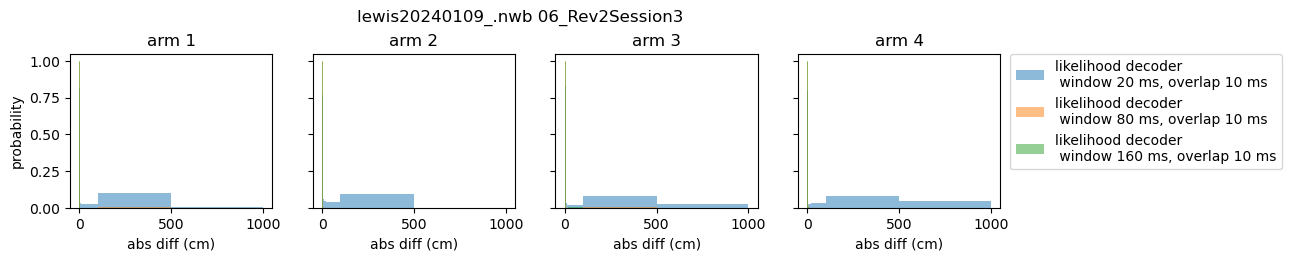

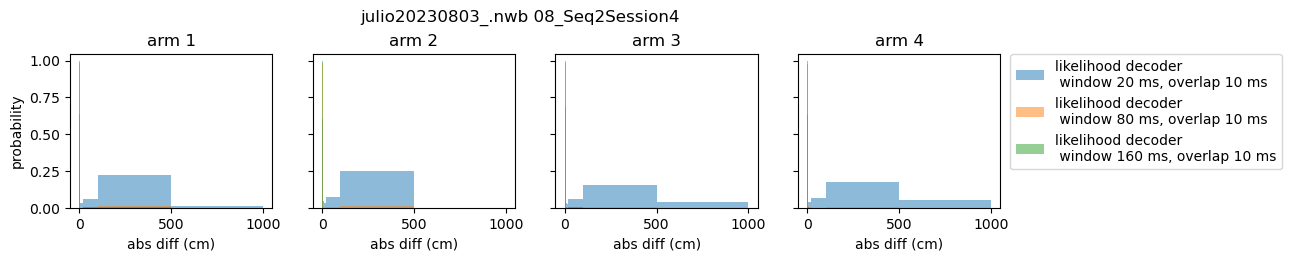

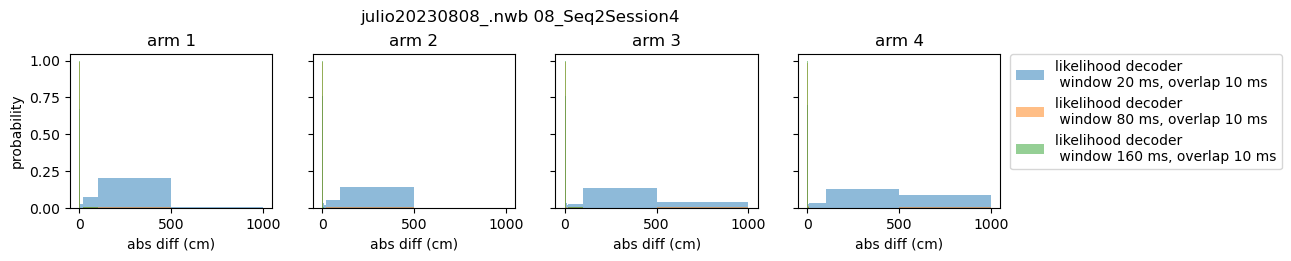

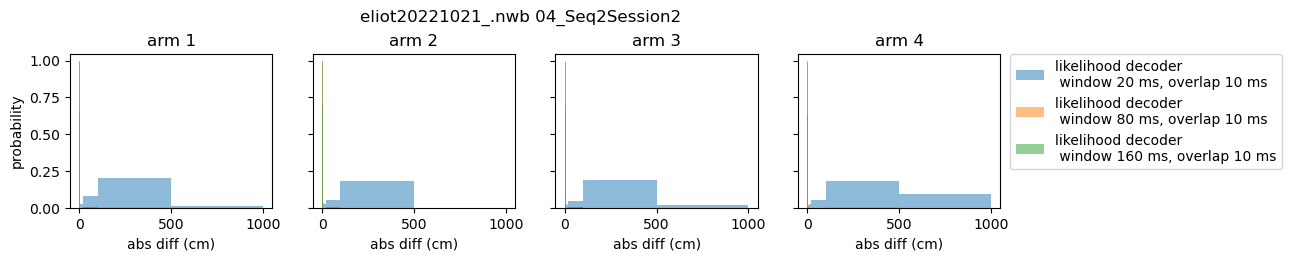

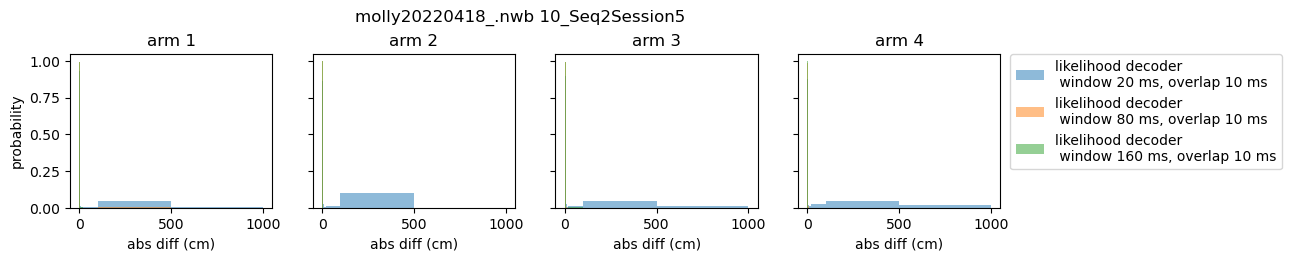

In [14]:
for file_ind in range(len(nwb_copy_file_name_all)):

    fig, axes = plt.subplots(1, 4, figsize=(12, 2),sharey = True)
    
    nwb_copy_file_name = nwb_copy_file_name_all[file_ind]
    session_name = sessions_all[file_ind]
    diff_file = diff_all[nwb_copy_file_name]
    
    for arm in [1,2,3,4]:
        color_ind = 0
        for classifier_param_name in diff_file.keys():
            label = f"likelihood decoder \n window {int(window_size[classifier_param_name]*1000)} ms, overlap {int(overlap_size[classifier_param_name]*1000)} ms" 
            diff = diff_file[classifier_param_name][arm]
            axes[arm-1].hist(diff,
                             bins = [0,5,10,20,100,500,1000],
                             weights = np.ones_like(diff)/len(diff),
                             color = "C"+str(color_ind), alpha = 0.5, label = label)
            color_ind += 1
    
    axes[0].set_title("arm 1")
    axes[1].set_title("arm 2")
    axes[2].set_title("arm 3")
    axes[3].set_title("arm 4")
    
    axes[0].set_ylabel("probability")
    for a in axes:
        a.set_xlabel("abs diff (cm)")
    a.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.suptitle(f"{nwb_copy_file_name} {session_name}",x=0.5, y=1.1)
    
    plt.savefig(f'decode_accuracy_{nwb_copy_file_name}_{session_name}.pdf',dpi=300,bbox_inches='tight')